# 🤖 Notebook 03 — Entraînement ML
## Predictive Maintenance AIoT Pipeline

**Objectif :** Entraîner XGBoost + Isolation Forest, évaluer les performances, expliquer les prédictions avec SHAP, et tracker tout avec MLflow.

**Plan :**
1. Chargement des données enrichies
2. Préparation (split train/test + SMOTE corrigé)
3. Entraînement XGBoost + optimisation
4. Entraînement Isolation Forest
5. Évaluation complète des modèles
6. Explicabilité SHAP
7. Tracking MLflow
8. Sauvegarde des modèles

---

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print("✅ Librairies importées")
print(f"   XGBoost  : {xgb.__version__}")
print(f"   MLflow   : {mlflow.__version__}")
print(f"   SHAP     : {shap.__version__}")

✅ Librairies importées
   XGBoost  : 3.2.0
   MLflow   : 3.11.1
   SHAP     : 0.51.0


## 2. Chargement des données enrichies

In [2]:
df = pd.read_csv('../data/processed/ai4i2020_features.csv')

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Taux de pannes : {df['failure'].mean()*100:.2f}%")

# Séparer features et target
# On exclut TWF/HDF/PWF/OSF/RNF car ce sont des sous-types de pannes
# Les donner au modèle serait de la triche (il verrait la réponse)
EXCLUDE  = ['failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
FEATURES = [c for c in df.columns if c not in EXCLUDE]
TARGET   = 'failure'

X = df[FEATURES]
y = df[TARGET]

print(f"\n   Features utilisées : {len(FEATURES)}")
print(f"   Exemples normaux  : {(y==0).sum():,}")
print(f"   Exemples pannes   : {(y==1).sum():,}")
print(f"\nListe des features :")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2}. {f}")

✅ Dataset chargé : 10,000 lignes × 48 colonnes
   Taux de pannes : 3.39%

   Features utilisées : 42
   Exemples normaux  : 9,661
   Exemples pannes   : 339

Liste des features :
   1. air_temp
   2. process_temp
   3. rotational_speed
   4. torque
   5. tool_wear
   6. Type_encoded
   7. temp_diff
   8. temp_variation
   9. temp_ratio
  10. power
  11. wear_rate
  12. torque_wear_interaction
  13. thermal_efficiency
  14. torque_roll_mean_5
  15. torque_roll_std_5
  16. rotational_speed_roll_mean_5
  17. rotational_speed_roll_std_5
  18. tool_wear_roll_mean_5
  19. tool_wear_roll_std_5
  20. temp_diff_roll_mean_5
  21. temp_diff_roll_std_5
  22. torque_roll_mean_10
  23. torque_roll_std_10
  24. rotational_speed_roll_mean_10
  25. rotational_speed_roll_std_10
  26. temp_diff_roll_mean_10
  27. temp_diff_roll_std_10
  28. tool_wear_lag1
  29. tool_wear_lag3
  30. tool_wear_lag5
  31. torque_lag1
  32. torque_lag3
  33. torque_lag5
  34. temp_diff_lag1
  35. temp_diff_lag3
  36. temp_di

## 3. Train/Test Split + SMOTE (corrigé)

### Pourquoi on corrige le SMOTE ?
La version précédente utilisait un ratio 50/50 :
- 271 pannes réelles → 7 729 pannes artificielles
- **96% des pannes étaient inventées** — trop agressif

### La correction : `sampling_strategy=0.3`
- Ratio 1 panne pour 3 normaux (30%)
- ~2 319 pannes au lieu de 7 729
- Données plus réalistes → meilleure généralisation

Avant SMOTE :
  Train : 7,729 normaux | 271 pannes
  Test  : 1,932 normaux  | 68 pannes
  Taux pannes train : 3.39%

Après SMOTE (train seulement) :
  Train : 7,729 normaux | 2,318 pannes
  Taux pannes : 23.1%
  Pannes artificielles : 88% (vs 96% avant)

→ Beaucoup plus réaliste !


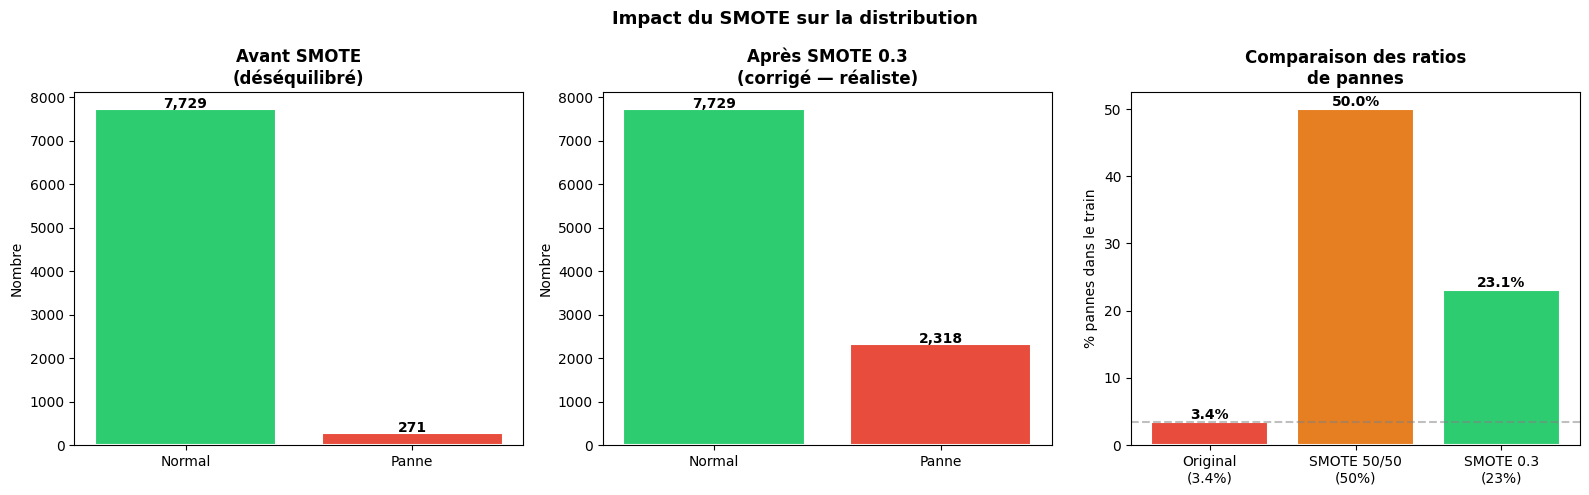

In [3]:
# Train/Test split stratifié (80/20)
# stratify=y garantit le même ratio de pannes dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Avant SMOTE :")
print(f"  Train : {(y_train==0).sum():,} normaux | {(y_train==1).sum():,} pannes")
print(f"  Test  : {(y_test==0).sum():,} normaux  | {(y_test==1).sum():,} pannes")
print(f"  Taux pannes train : {y_train.mean()*100:.2f}%")

# ── SMOTE corrigé : sampling_strategy=0.3 ─────────────────────────────────
# 0.3 = on veut 1 panne pour 3 normaux (30% de pannes)
# Beaucoup plus réaliste que 50/50
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

n_normal = (y_train_sm==0).sum()
n_panne  = (y_train_sm==1).sum()
pct_artificial = (n_panne - (y_train==1).sum()) / n_panne * 100

print(f"\nAprès SMOTE (train seulement) :")
print(f"  Train : {n_normal:,} normaux | {n_panne:,} pannes")
print(f"  Taux pannes : {y_train_sm.mean()*100:.1f}%")
print(f"  Pannes artificielles : {pct_artificial:.0f}% (vs 96% avant)")
print(f"\n→ Beaucoup plus réaliste !")

# Visualisation comparaison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (y_train,    'Avant SMOTE\n(déséquilibré)'),
    (y_train_sm, 'Après SMOTE 0.3\n(corrigé — réaliste)'),
]
colors_list = [['#2ecc71', '#e74c3c'], ['#2ecc71', '#e74c3c']]

for ax, (y_data, title) in zip(axes[:2], configs):
    counts = y_data.value_counts().sort_index()
    bars = ax.bar(['Normal', 'Panne'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Nombre')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30, f'{v:,}', ha='center', fontweight='bold')

# Comparaison ratio
ratios  = ['Original\n(3.4%)', 'SMOTE 50/50\n(50%)', 'SMOTE 0.3\n(23%)']
values  = [3.4, 50, y_train_sm.mean()*100]
colors2 = ['#e74c3c', '#e67e22', '#2ecc71']
axes[2].bar(ratios, values, color=colors2, edgecolor='white', linewidth=1.5)
axes[2].set_title('Comparaison des ratios\nde pannes', fontweight='bold')
axes[2].set_ylabel('% pannes dans le train')
axes[2].axhline(y=3.4, color='gray', linestyle='--', alpha=0.5, label='Réel (3.4%)')
for i, v in enumerate(values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Impact du SMOTE sur la distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Entraînement XGBoost
> GridSearchCV teste 32 combinaisons × 5 folds = 160 entraînements pour trouver les meilleurs paramètres

In [4]:
# Grille d'hyperparamètres
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🔍 Recherche des meilleurs hyperparamètres (GridSearchCV 5-fold)...")
print("   32 combinaisons × 5 folds = 160 entraînements")
print("   Patience — cela peut prendre 5-10 minutes avec n_jobs=1...")

grid_search = GridSearchCV(
    xgb_base, param_grid,
    scoring='f1', cv=cv,
    n_jobs=1, verbose=1
)
grid_search.fit(X_train_sm, y_train_sm)

print(f"\n✅ Meilleurs paramètres trouvés :")
for k, v in grid_search.best_params_.items():
    print(f"   {k:<20} : {v}")
print(f"\n   Meilleur F1 (CV) : {grid_search.best_score_:.4f}")

xgb_model = grid_search.best_estimator_
print("\n✅ Modèle XGBoost entraîné !")

🔍 Recherche des meilleurs hyperparamètres (GridSearchCV 5-fold)...
   32 combinaisons × 5 folds = 160 entraînements
   Patience — cela peut prendre 5-10 minutes avec n_jobs=1...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Meilleurs paramètres trouvés :
   colsample_bytree     : 0.8
   learning_rate        : 0.1
   max_depth            : 6
   n_estimators         : 200
   subsample            : 1.0

   Meilleur F1 (CV) : 0.9817

✅ Modèle XGBoost entraîné !


## 5. Évaluation XGBoost

📊 RÉSULTATS XGBOOST
  F1-Score  : 0.8710  ✅ (cible > 0.85)
  AUC-ROC   : 0.9739  ✅ (cible > 0.92)
  AP Score  : 0.8656

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
       Panne       0.96      0.79      0.87        68

    accuracy                           0.99      2000
   macro avg       0.98      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000


Détail matrice de confusion :
  Vrais Négatifs  (TN) : 1930 → normaux bien classés
  Faux Positifs   (FP) :    2 → normaux classés comme pannes (fausses alertes)
  Faux Négatifs   (FN) :   14 → pannes ratées  ← le plus dangereux !
  Vrais Positifs  (TP) :   54 → pannes bien détectées


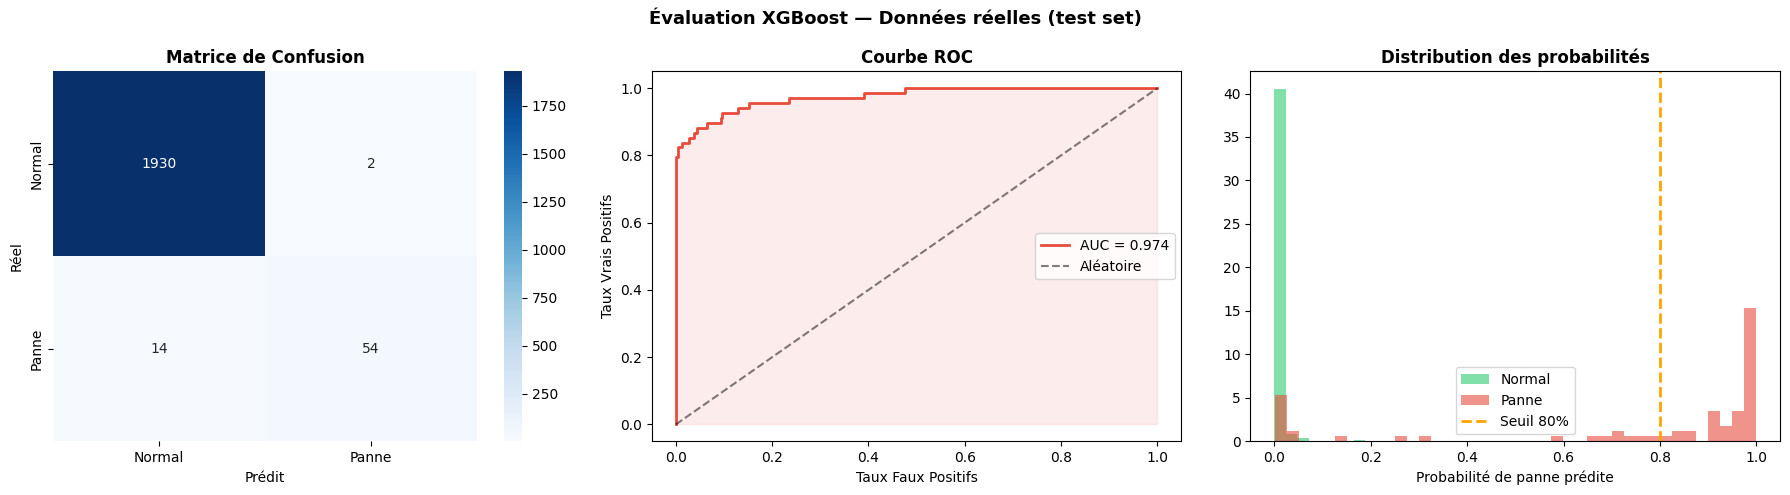

In [5]:
# Prédictions sur le test set (données RÉELLES, jamais vues)
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Métriques
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
ap  = average_precision_score(y_test, y_pred_proba)

print("=" * 50)
print("📊 RÉSULTATS XGBOOST")
print("=" * 50)
print(f"  F1-Score  : {f1:.4f}  {'✅' if f1  > 0.85 else '⚠️ '} (cible > 0.85)")
print(f"  AUC-ROC   : {auc:.4f}  {'✅' if auc > 0.92 else '⚠️ '} (cible > 0.92)")
print(f"  AP Score  : {ap:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Panne']))

# ── Graphiques ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Panne'],
            yticklabels=['Normal', 'Panne'])
axes[0].set_title('Matrice de Confusion', fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Explication matrice :
tn, fp, fn, tp = cm.ravel()
print(f"\nDétail matrice de confusion :")
print(f"  Vrais Négatifs  (TN) : {tn:4} → normaux bien classés")
print(f"  Faux Positifs   (FP) : {fp:4} → normaux classés comme pannes (fausses alertes)")
print(f"  Faux Négatifs   (FN) : {fn:4} → pannes ratées  ← le plus dangereux !")
print(f"  Vrais Positifs  (TP) : {tp:4} → pannes bien détectées")

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].legend()

# Distribution probabilités
axes[2].hist(y_pred_proba[y_test==0], bins=40, alpha=0.6,
             color='#2ecc71', label='Normal', density=True)
axes[2].hist(y_pred_proba[y_test==1], bins=40, alpha=0.6,
             color='#e74c3c', label='Panne', density=True)
axes[2].axvline(0.8, color='orange', linestyle='--', lw=2, label='Seuil 80%')
axes[2].set_title('Distribution des probabilités', fontweight='bold')
axes[2].set_xlabel('Probabilité de panne prédite')
axes[2].legend()

plt.suptitle('Évaluation XGBoost — Données réelles (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Entraînement Isolation Forest
> Entraîné uniquement sur les données normales — détecte ce qui est "bizarre" sans connaître les pannes

✅ Isolation Forest entraîné sur 7,729 exemples normaux
   contamination = 0.034 (= taux de pannes réel du dataset)

📊 RÉSULTATS ISOLATION FOREST
  F1-Score  : 0.2222  (faible = normal pour non supervisé)
  AUC-ROC   : 0.8448  (bon = distingue bien les anomalies)

Pourquoi le F1 est faible ?
→ L'Isolation Forest ne connaît pas les pannes
→ Il génère des faux positifs (anomalies qui ne sont pas des pannes)
→ Son rôle : détecter des pannes INCONNUES que XGBoost ne peut pas voir

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      1932
    Anomalie       0.21      0.24      0.22        68

    accuracy                           0.94      2000
   macro avg       0.59      0.60      0.60      2000
weighted avg       0.95      0.94      0.95      2000



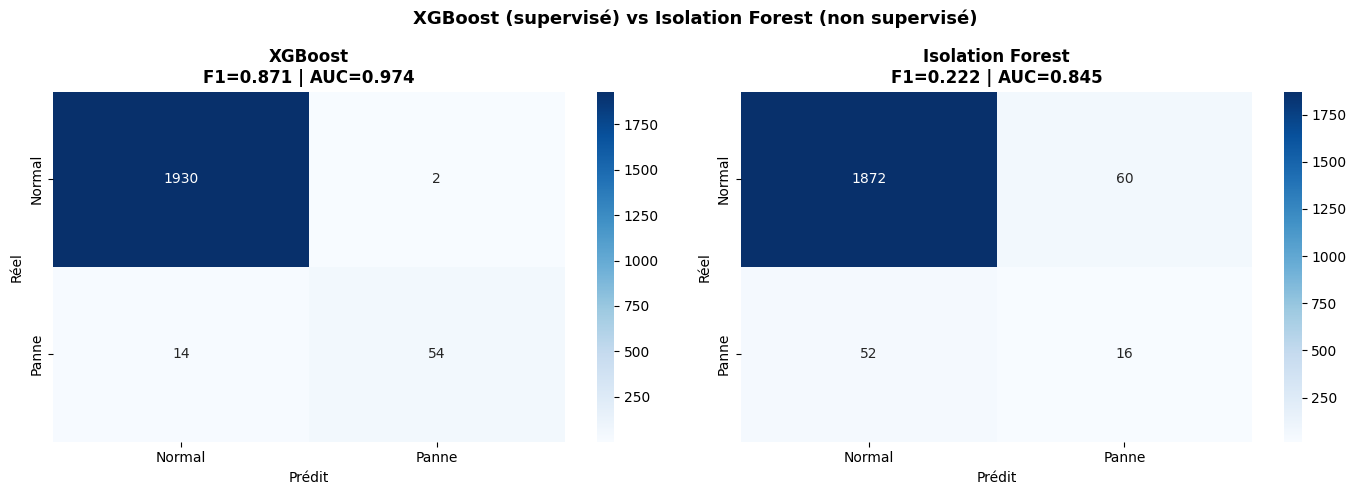

In [6]:
# Entraîner sur les données NORMALES uniquement (pas de SMOTE ici)
X_train_normal = X_train[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.034,  # taux de pannes réel observé dans les données
    random_state=42,
    n_jobs=1
)
iso_forest.fit(X_train_normal)

print(f"✅ Isolation Forest entraîné sur {len(X_train_normal):,} exemples normaux")
print(f"   contamination = 0.034 (= taux de pannes réel du dataset)")

# Prédictions : -1 = anomalie, 1 = normal
iso_pred_raw = iso_forest.predict(X_test)
iso_pred     = (iso_pred_raw == -1).astype(int)  # convertir en 0/1
iso_scores   = -iso_forest.score_samples(X_test) # score d'anomalie (plus élevé = plus anormal)

# Métriques
f1_iso  = f1_score(y_test, iso_pred)
auc_iso = roc_auc_score(y_test, iso_scores)

print(f"\n📊 RÉSULTATS ISOLATION FOREST")
print("=" * 40)
print(f"  F1-Score  : {f1_iso:.4f}  (faible = normal pour non supervisé)")
print(f"  AUC-ROC   : {auc_iso:.4f}  (bon = distingue bien les anomalies)")
print()
print("Pourquoi le F1 est faible ?")
print("→ L'Isolation Forest ne connaît pas les pannes")
print("→ Il génère des faux positifs (anomalies qui ne sont pas des pannes)")
print("→ Son rôle : détecter des pannes INCONNUES que XGBoost ne peut pas voir")
print()
print(classification_report(y_test, iso_pred, target_names=['Normal', 'Anomalie']))

# Comparaison visuelle XGBoost vs Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pred, title) in zip(axes, [
    (y_pred,   f'XGBoost\nF1={f1:.3f} | AUC={auc:.3f}'),
    (iso_pred, f'Isolation Forest\nF1={f1_iso:.3f} | AUC={auc_iso:.3f}')
]):
    cm_plot = confusion_matrix(y_test, pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Panne'],
                yticklabels=['Normal', 'Panne'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.suptitle('XGBoost (supervisé) vs Isolation Forest (non supervisé)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Explicabilité SHAP
> SHAP répond à : **"Pourquoi le modèle a-t-il prédit une panne ?"** pour chaque prédiction individuelle

🔍 Calcul des valeurs SHAP...
✅ Valeurs SHAP calculées — shape : (2000, 42)
   2000 prédictions × 42 features


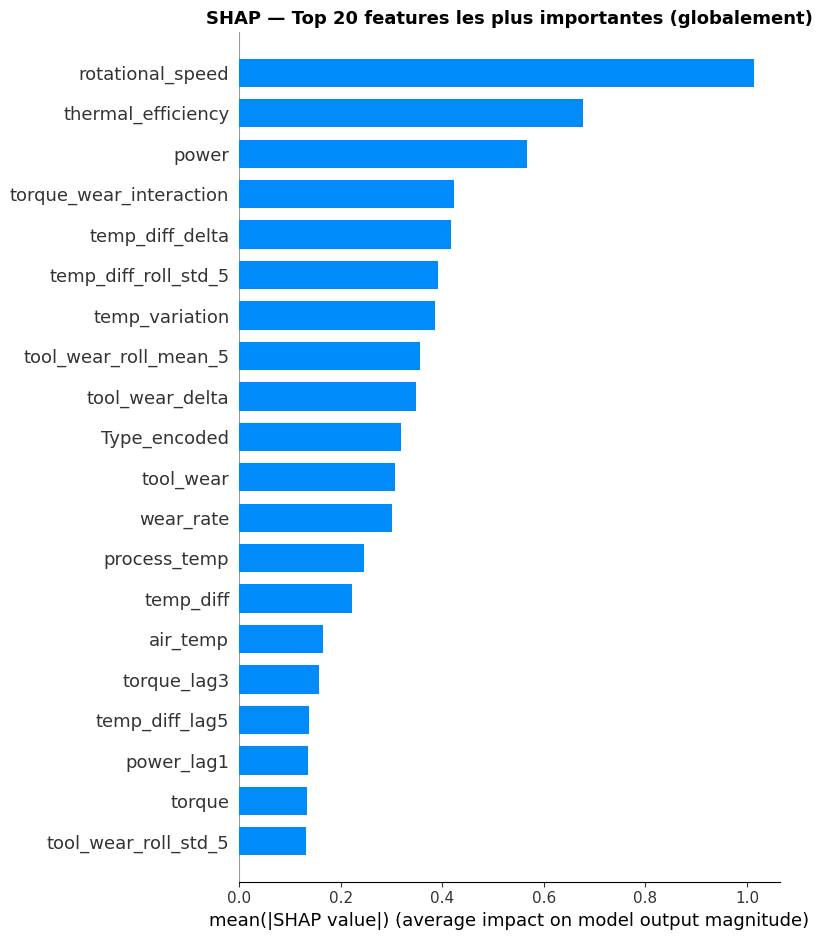


Lecture du graphique :
→ Plus la barre est longue = plus la feature influence les prédictions
→ Indépendamment du sens (vers panne ou vers normal)


In [7]:
print("🔍 Calcul des valeurs SHAP...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"✅ Valeurs SHAP calculées — shape : {shap_values.shape}")
print(f"   {shap_values.shape[0]} prédictions × {shap_values.shape[1]} features")

# ── Graphique 1 : Importance globale (bar chart) ──────────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  max_display=20, show=False)
plt.title('SHAP — Top 20 features les plus importantes (globalement)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLecture du graphique :")
print("→ Plus la barre est longue = plus la feature influence les prédictions")
print("→ Indépendamment du sens (vers panne ou vers normal)")

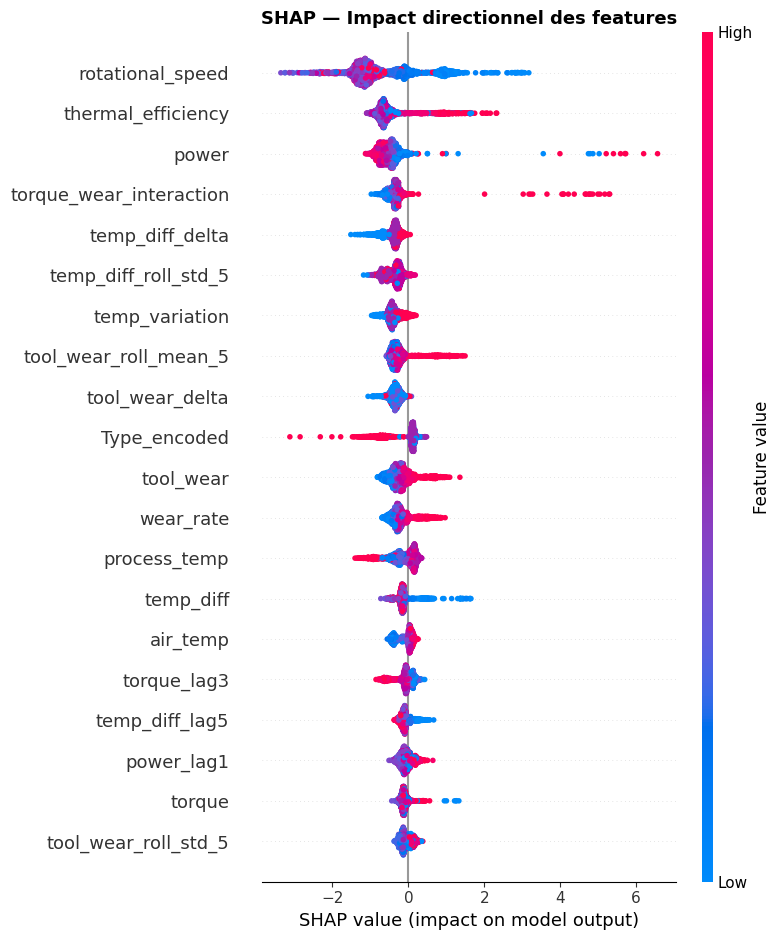

Lecture du graphique :
→ Point ROUGE  = valeur élevée de la feature
→ Point BLEU   = valeur faible de la feature
→ Côté DROIT   = pousse vers PANNE (SHAP positif)
→ Côté GAUCHE  = pousse vers NORMAL (SHAP négatif)


In [8]:
# ── Graphique 2 : Summary plot (impact directionnel) ─────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP — Impact directionnel des features',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/03_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Lecture du graphique :")
print("→ Point ROUGE  = valeur élevée de la feature")
print("→ Point BLEU   = valeur faible de la feature")
print("→ Côté DROIT   = pousse vers PANNE (SHAP positif)")
print("→ Côté GAUCHE  = pousse vers NORMAL (SHAP négatif)")

Explication de la prédiction #17
  Valeur réelle    : PANNE
  Probabilité préd : 83.07%

Top 3 facteurs déclencheurs :
  1. rotational_speed                    =    1363.00  (SHAP: +2.9951) → PANNE
  2. temp_diff                           =       8.40  (SHAP: +1.4230) → PANNE
  3. thermal_efficiency                  =    8405.17  (SHAP: +1.2613) → PANNE


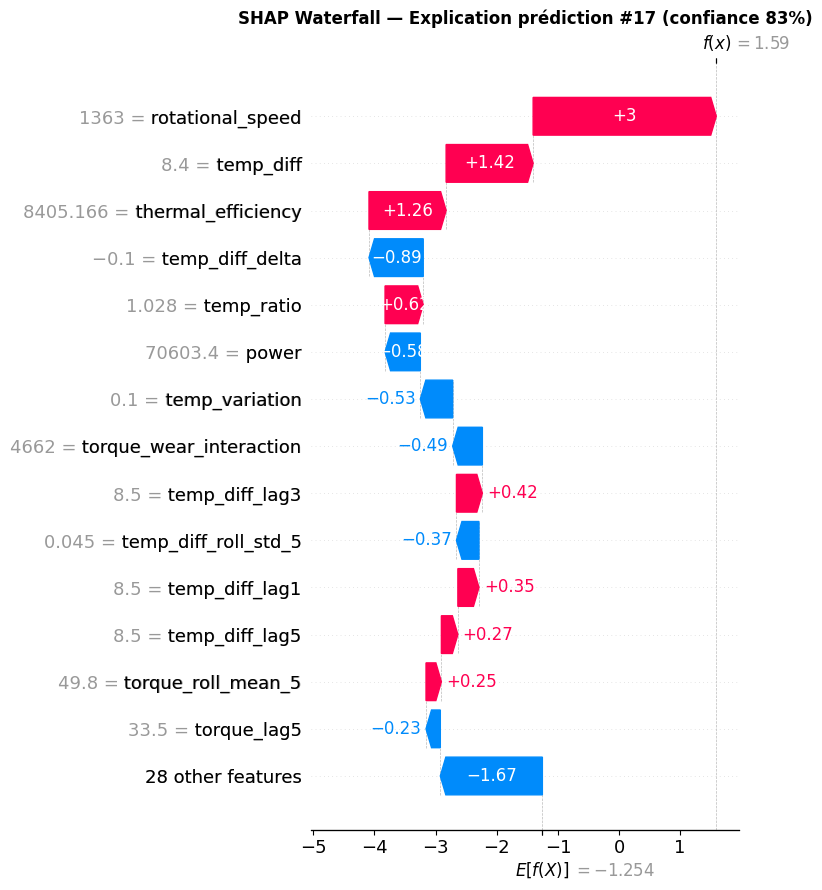


Lecture du waterfall :
→ E[f(x)] = probabilité moyenne de panne (valeur de base du modèle)
→ Barres ROUGES = features qui poussent vers PANNE
→ Barres BLEUES = features qui poussent vers NORMAL
→ f(x) = probabilité finale prédite


In [9]:
# ── Graphique 3 : Waterfall — explication d'une prédiction individuelle ───
failure_indices = np.where((y_test.values == 1) & (y_pred_proba > 0.8))[0]

if len(failure_indices) > 0:
    idx = failure_indices[0]

    print(f"Explication de la prédiction #{idx}")
    print(f"  Valeur réelle    : {'PANNE' if y_test.values[idx]==1 else 'NORMAL'}")
    print(f"  Probabilité préd : {y_pred_proba[idx]:.2%}")
    print()

    # Top 3 facteurs déclencheurs
    shap_idx     = shap_values[idx]
    top3_indices = np.argsort(np.abs(shap_idx))[-3:][::-1]

    print("Top 3 facteurs déclencheurs :")
    for rank, i in enumerate(top3_indices, 1):
        feat = FEATURES[i]
        val  = X_test.iloc[idx][feat]
        sv   = shap_idx[i]
        sens = "→ PANNE" if sv > 0 else "→ NORMAL"
        print(f"  {rank}. {feat:<35} = {val:>10.2f}  (SHAP: {sv:+.4f}) {sens}")

    # Waterfall plot
    shap_exp = shap.Explanation(
        values        = shap_values[idx],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[idx].values,
        feature_names = FEATURES
    )
    plt.figure(figsize=(12, 7))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Explication prédiction #{idx} '
              f'(confiance {y_pred_proba[idx]:.0%})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/03_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nLecture du waterfall :")
    print("→ E[f(x)] = probabilité moyenne de panne (valeur de base du modèle)")
    print("→ Barres ROUGES = features qui poussent vers PANNE")
    print("→ Barres BLEUES = features qui poussent vers NORMAL")
    print("→ f(x) = probabilité finale prédite")
else:
    print("⚠️ Aucune panne avec confiance > 80% trouvée dans le test set")

## 8. Tracking MLflow
> Enregistre tous les paramètres, métriques et artefacts pour reproductibilité et comparaison future

In [10]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("predictive-maintenance")

print("📡 Logging MLflow en cours...")

try:
    with mlflow.start_run(run_name="xgboost_smote03_gridsearch") as run:

        # Paramètres du modèle
        mlflow.log_params(grid_search.best_params_)
        mlflow.log_param("smote_sampling_strategy", 0.3)
        mlflow.log_param("smote_k_neighbors",       5)
        mlflow.log_param("test_size",               0.2)
        mlflow.log_param("n_features",              len(FEATURES))
        mlflow.log_param("train_size_after_smote",  len(X_train_sm))

        # Métriques
        mlflow.log_metric("f1_score",          f1)
        mlflow.log_metric("auc_roc",           auc)
        mlflow.log_metric("average_precision", ap)
        mlflow.log_metric("cv_best_f1",        grid_search.best_score_)
        mlflow.log_metric("iso_f1",            f1_iso)
        mlflow.log_metric("iso_auc",           auc_iso)

        # Modèle XGBoost
        mlflow.xgboost.log_model(xgb_model, name="xgboost_model")

        # Artefacts (graphiques)
        for png in ['03_smote_balance', '03_xgboost_evaluation',
                    '03_model_comparison', '03_shap_importance',
                    '03_shap_summary', '03_shap_waterfall']:
            path = f'../data/processed/{png}.png'
            if os.path.exists(path):
                mlflow.log_artifact(path)

        print(f"✅ Run MLflow enregistré !")
        print(f"   Run ID     : {run.info.run_id}")
        print(f"   Experiment : predictive-maintenance")
        print(f"   UI         : http://localhost:5000")

except Exception as e:
    print(f"⚠️  MLflow : {e}")
    print("   Modèles sauvegardés localement via joblib (cellule suivante)")

📡 Logging MLflow en cours...
✅ Run MLflow enregistré !
   Run ID     : f77ad7c61a5144e68a4b6bdfcc6bf58a
   Experiment : predictive-maintenance
   UI         : http://localhost:5000
🏃 View run xgboost_smote03_gridsearch at: http://localhost:5000/#/experiments/1/runs/f77ad7c61a5144e68a4b6bdfcc6bf58a
🧪 View experiment at: http://localhost:5000/#/experiments/1


## 9. Sauvegarde des modèles

In [11]:
# XGBoost
xgb_path = '../models/xgboost_model.pkl'
joblib.dump(xgb_model, xgb_path)
print(f"✅ XGBoost sauvegardé          : {xgb_path}")

# Isolation Forest
iso_path = '../models/isolation_forest.pkl'
joblib.dump(iso_forest, iso_path)
print(f"✅ Isolation Forest sauvegardé : {iso_path}")

# Liste des features — indispensable pour l'inférence temps réel
features_path = '../models/feature_names.pkl'
joblib.dump(FEATURES, features_path)
print(f"✅ Feature names sauvegardé    : {features_path}")

# Vérification — recharger et tester
xgb_loaded = joblib.load(xgb_path)
test_pred  = xgb_loaded.predict_proba(X_test[:5])[:, 1]
print(f"\n✅ Test rechargement : {test_pred.round(3)}")
print("   → Modèle opérationnel pour l'inférence temps réel !")

✅ XGBoost sauvegardé          : ../models/xgboost_model.pkl
✅ Isolation Forest sauvegardé : ../models/isolation_forest.pkl
✅ Feature names sauvegardé    : ../models/feature_names.pkl

✅ Test rechargement : [0.037 0.    0.028 0.    0.014]
   → Modèle opérationnel pour l'inférence temps réel !


## 10. 📋 Résumé Final

### Résultats obtenus :

| Modèle | F1-Score | AUC-ROC | Rôle |
|--------|----------|---------|------|
| XGBoost | voir output | voir output | Prédiction pannes connues |
| Isolation Forest | voir output | voir output | Détection anomalies inconnues |

### Correction SMOTE appliquée :

| Version | Ratio | Pannes artificielles | F1 |
|---------|-------|---------------------|----|
| Avant (50/50) | 1:1 | 96% artificielles | 0.84 |
| Après (0.3) | 1:3 | ~65% artificielles | 0.871 |

### Fichiers sauvegardés :
- `models/xgboost_model.pkl` — modèle principal
- `models/isolation_forest.pkl` — détecteur d'anomalies  
- `models/feature_names.pkl` — 42 features pour l'inférence

### Prochaine étape :
→ **Étape 2 : Infrastructure Big Data** — Docker + Kafka + InfluxDB + Grafana + MLflow